In [ ]:
# @title 1. Install & Load Data (Fixed Filename Parsing)
!pip install torchdiffeq torch_geometric scatter pandas numpy matplotlib openpyxl

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torchdiffeq import odeint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from google.colab import files as colab_files

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.2/354.2 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.6/821.6 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.8/959.8 kB 74.5 MB/s eta 0:00:00
Using device: cuda


In [ ]:
def get_files():
    # 1. Look for files in current directory (both formats)
    extensions = ['*.csv', '*.xlsx', '*.xls']
    found_files = []
    for ext in extensions:
        found_files.extend(glob.glob(ext))

    # 2. Filter for Witvliet files specifically
    target_files = [f for f in found_files if "witvliet" in f.lower()]

    # 3. If missing, force upload
    if len(target_files) < 8:
        print(f"\nFound only {len(target_files)}/8 files.")
        print("Please click 'Choose Files' below and upload all 8 Witvliet files.")

        uploaded = colab_files.upload()

        # Re-scan after upload
        found_files = []
        for ext in extensions:
            found_files.extend(glob.glob(ext))
        target_files = [f for f in found_files if "witvliet" in f.lower()]

    print(f"\nSuccessfully recognized {len(target_files)} files: {target_files}")
    return sorted(target_files)

def parse_stage(filename):

    name = filename.lower()

    # 1. Try explicit names first
    if 'l1' in name: return 0.0
    if 'l2' in name: return 1.0
    if 'l3' in name: return 2.0
    if 'adult' in name: return 3.0

    # 2. Fallback: Extract number from filename (e.g., witvliet_2020_1.xlsx)
    match = re.search(r'witvliet_2020_(\d)', name)
    if match:
        num = int(match.group(1))
        if 1 <= num <= 4: return 0.0 # L1
        if num == 5: return 1.0      # L2
        if num == 6: return 2.0      # L3
        if num >= 7: return 3.0      # Adult

    return None

def read_file(fpath):

    if fpath.endswith('.xlsx') or fpath.endswith('.xls'):
        return pd.read_excel(fpath)
    else:
        return pd.read_csv(fpath)

def process_data(file_list):
    # 1. Build Superset of Neurons (Nodes)
    all_neurons = set()
    valid_files = []

    print("Building neuron index...")
    for fpath in file_list:
        try:
            df = read_file(fpath)

            # Standardize columns (handling Excel variations)
            cols = [c.lower() for c in df.columns]
            df.columns = cols

            # Simple normalization map
            rename_map = {}
            for c in cols:
                if 'pre' in c: rename_map[c] = 'pre'
                elif 'post' in c: rename_map[c] = 'post'
                elif 'syn' in c: rename_map[c] = 'synapses'
            df.rename(columns=rename_map, inplace=True)

            if 'pre' in df.columns and 'post' in df.columns:
                # Add all unique names to set
                all_neurons.update(df['pre'].astype(str).unique())
                all_neurons.update(df['post'].astype(str).unique())

                t = parse_stage(fpath)
                print(f"File: {fpath} -> Mapped to Time: {t}") # Debug Print

                if t is not None:
                    valid_files.append({'t': t, 'df': df})
            else:
                print(f"Skipping {fpath}: Columns 'pre'/'post' missing after normalization.")
        except Exception as e:
            print(f"Error reading {fpath}: {e}")

    # Create Dictionary: Name -> ID
    neuron_map = {name: i for i, name in enumerate(sorted(list(all_neurons)))}
    num_nodes = len(neuron_map)
    print(f"Total Unique Neurons: {num_nodes}")

    # 2. Convert to Adjacency Matrices grouped by Time
    data_by_time = {}

    for item in valid_files:
        t = item['t']
        df = item['df']

        # Create empty matrix
        adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)

        for _, row in df.iterrows():
            pre, post = str(row['pre']), str(row['post'])
            if pre in neuron_map and post in neuron_map:
                src, dst = neuron_map[pre], neuron_map[post]
                # Log-normalize weight
                val = row['synapses'] if 'synapses' in row else 1.0
                try:
                    w = np.log1p(float(val))
                except:
                    w = 1.0
                adj[src, dst] += w

        if t not in data_by_time: data_by_time[t] = []
        data_by_time[t].append(adj)

    return data_by_time, neuron_map, num_nodes

files_list = get_files()
data_map, neuron_map, NUM_NODES = process_data(files_list)

print(f"Available Time Keys: {sorted(data_map.keys())}")


Successfully recognized 8 files: ['witvliet_2020_2.xlsx', 'witvliet_2020_3.xlsx', 'witvliet_2020_8.xlsx', 'witvliet_2020_4.xlsx', 'witvliet_2020_7.xlsx', 'witvliet_2020_5.xlsx', 'witvliet_2020_1.xlsx', 'witvliet_2020_6.xlsx']
Building neuron index...
File: witvliet_2020_1.xlsx -> Mapped to Time: 0.0
File: witvliet_2020_2.xlsx -> Mapped to Time: 0.0
File: witvliet_2020_3.xlsx -> Mapped to Time: 0.0
File: witvliet_2020_4.xlsx -> Mapped to Time: 0.0
File: witvliet_2020_5.xlsx -> Mapped to Time: 1.0
File: witvliet_2020_6.xlsx -> Mapped to Time: 2.0
File: witvliet_2020_7.xlsx -> Mapped to Time: 3.0
File: witvliet_2020_8.xlsx -> Mapped to Time: 3.0
Total Unique Neurons: 225
Available Time Keys: [0.0, 1.0, 2.0, 3.0]


In [ ]:
# @title 2. Prepare Training Tensors

# 1. Create Input: The "Seed" Brain (Average L1)
# We take all matrices at Time 0.0 (Files 1-4) and average them
l1_matrices = torch.stack(data_map[0.0])
avg_l1 = torch.mean(l1_matrices, dim=0).to(device)

# Convert L1 to sparse format (Edge Index) for the GCN Encoder
# This tells the model: "Here is the starting topology"
edge_index = avg_l1.nonzero().t()
edge_weight = avg_l1[edge_index[0], edge_index[1]]

# Node Features: Identity Matrix (One-hot encoding)
# This allows the model to learn unique traits for each neuron
x_init = torch.eye(NUM_NODES).to(device)

# 2. Create Targets: The Ground Truth for [L1, L2, L3, Adult]
sorted_times = sorted(data_map.keys())
target_times = torch.tensor(sorted_times).float().to(device)

print(f"Training on Time Points: {sorted_times}")

# Create a stack of Ground Truth matrices: Shape [4, N, N]
gt_list = []
for t in sorted_times:
    mats = torch.stack(data_map[t])
    # Average them to get the 'canonical' connectome for this stage
    gt_list.append(torch.mean(mats, dim=0).to(device))

gt_stack = torch.stack(gt_list)

print(f"Ground Truth Shape: {gt_stack.shape}")
print("Data Preparation Complete.")

Training on Time Points: [0.0, 1.0, 2.0, 3.0]
Ground Truth Shape: torch.Size([4, 225, 225])
Data Preparation Complete.


In [ ]:
# @title 3. Define Connectome-ODE Architecture

class ODEFunc(nn.Module):
    """
    Learns the differential equation: dZ/dt = NeuralNet(Z)
    """
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(), # Tanh is numerically more stable for ODEs
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, t, z):
        return self.net(z)

class ConnectomeODE(nn.Module):
    def __init__(self, num_nodes, hidden_dim=64):
        super(ConnectomeODE, self).__init__()

        # ENCODER (Spatial): GCN
        # Compresses the sparse L1 graph into dense embeddings
        self.encoder = GCNConv(num_nodes, hidden_dim)

        # PROCESSOR (Temporal): Neural ODE
        # Simulates continuous evolution
        self.ode_func = ODEFunc(hidden_dim)

        # DECODER: Inner Product
        # Reconstructs graph: Probability(Link) = Sigmoid(Z . Z_transpose)
        self.scale = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, edge_index, edge_weight, t_span):
        # Encode the Initial State (L1)
        z0 = self.encoder(x, edge_index, edge_weight)

        # Integrate Forward in Time
        # Solves the ODE to get Z at every requested time in t_span
        z_t = odeint(self.ode_func, z0, t_span, rtol=1e-3, atol=1e-4)

        # Decode (Reconstruct Adjacency Matrices)
        predictions = []
        for i in range(len(t_span)):
            z = z_t[i]
            # Link Prediction
            logits = torch.mm(z, z.t()) * self.scale
            predictions.append(logits)

        return torch.stack(predictions)

print("Model Architecture Defined.")

Model Architecture Defined.


Epoch 0 | Loss: 2.0585
Epoch 200 | Loss: 0.7351
Epoch 400 | Loss: 0.7203
Epoch 600 | Loss: 0.7158
Epoch 800 | Loss: 0.7081
Epoch 1000 | Loss: 0.7030
Epoch 1200 | Loss: 0.6999
Epoch 1400 | Loss: 0.6983
Epoch 1600 | Loss: 0.6958
Epoch 1800 | Loss: 0.6954
Epoch 2000 | Loss: 0.6921


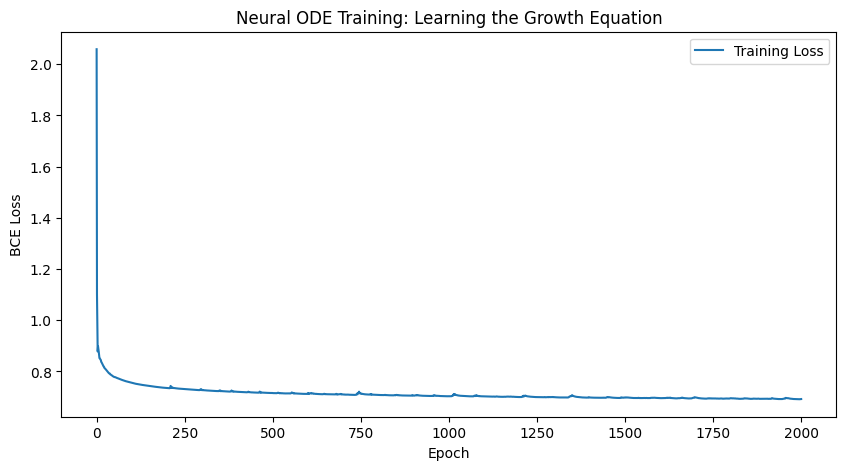

In [ ]:
# @title 4. Training the Model

HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 2000
POS_WEIGHT = 5.0 # Weight positive connections 5x more than negatives

model = ConnectomeODE(NUM_NODES, hidden_dim=HIDDEN_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT]).to(device))

losses = []

for epoch in range(EPOCHS + 1):
    optimizer.zero_grad()

    pred_logits = model(x_init, edge_index, edge_weight, target_times)

    loss = 0
    for i in range(len(target_times)):
        # Binarize GT for Link Prediction task
        gt_binary = (gt_stack[i] > 0).float()

        loss += criterion(pred_logits[i], gt_binary)

    # Average loss across time steps
    loss = loss / len(target_times)


    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.title("Neural ODE Training: Learning the Growth Equation")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.show()

Generating Continuous Development Video...


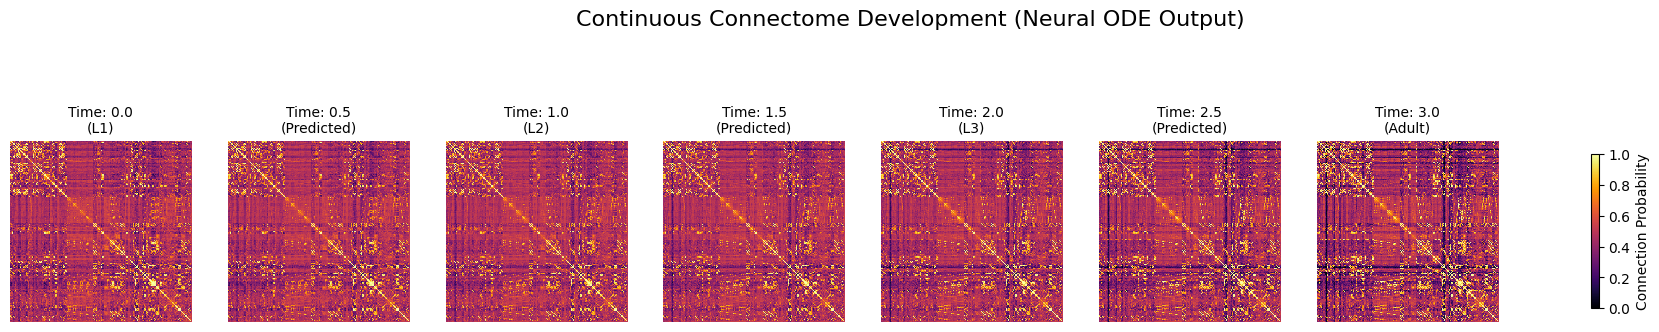

Visualization Complete.


In [ ]:
# @title 5. Generate "The Missing Frames" (Interpolation)

print("Generating Continuous Development Video...")

model.eval()
with torch.no_grad():

    interp_times = torch.linspace(0, 3, 7).to(device)

    # Run the simulation
    pred_interp = model(x_init, edge_index, edge_weight, interp_times)

    # Visualization
    fig, axes = plt.subplots(1, 7, figsize=(24, 4))

    for i in range(7):
        t = interp_times[i].item()

        # Convert logits to probability (Sigmoid)
        adj = torch.sigmoid(pred_interp[i]).cpu().numpy()

        # Plot Heatmap
        im = axes[i].imshow(adj, cmap='inferno', vmin=0, vmax=1, interpolation='none')

        # Create Title
        stage_name = ""
        if t == 0.0: stage_name = "(L1)"
        elif t == 1.0: stage_name = "(L2)"
        elif t == 2.0: stage_name = "(L3)"
        elif t == 3.0: stage_name = "(Adult)"
        else: stage_name = "(Predicted)"

        axes[i].set_title(f"Time: {t:.1f}\n{stage_name}", fontsize=10)
        axes[i].axis('off')

    # Add colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
    cbar.set_label("Connection Probability")

    plt.suptitle("Continuous Connectome Development (Neural ODE Output)", fontsize=16, y=1.05)
    plt.show()

print("Visualization Complete.")

In [ ]:
# @title 6. Interactive Network Visualization (Fixed)
!pip install pyvis

import networkx as nx
from pyvis.network import Network
from IPython.display import display, HTML
import numpy as np

# 1. Reverse the Map: We need Names (e.g., "ADAL"), not IDs (0, 1...)
id_to_name = {v: k for k, v in neuron_map.items()}

def visualize_brain_stage(time_point, threshold=0.7):
    """
    Generates an interactive HTML graph for a specific developmental time.
    threshold: Only show connections with probability > 0.7 (to keep it clean)
    """
    print(f"Generating Interactive Brain for Time t={time_point}...")

    # A. Get Model Prediction
    model.eval()
    with torch.no_grad():
        t_tensor = torch.tensor([float(time_point)]).to(device)
        pred_logit = model(x_init, edge_index, edge_weight, t_tensor)[0]
        adj_prob = torch.sigmoid(pred_logit).cpu().numpy()

    # B. Build the NetworkX Graph
    G = nx.DiGraph()

    # Add Nodes
    for i in range(NUM_NODES):
        name = id_to_name[i]
        G.add_node(int(i), label=name, title=name, color='#97C2FC')

    # Add Edges (Only strong ones!)
    rows, cols = np.where(adj_prob > threshold)

    edge_count = 0
    for r, c in zip(rows, cols):
        if r != c:
            # --- THE FIX IS HERE ---
            # Convert numpy.int64 to standard python int
            r_idx = int(r)
            c_idx = int(c)

            weight = float(adj_prob[r, c])
            G.add_edge(r_idx, c_idx, value=weight, title=f"Prob: {weight:.2f}", color='#FF0000')
            edge_count += 1

    print(f"   -> Nodes: {NUM_NODES}, Edges: {edge_count} (showing >{threshold*100}%)")

    # C. Visualize with PyVis
    # Using specific height and cdn settings for Colab compatibility
    net = Network(height="750px", width="100%", notebook=True, cdn_resources='remote', directed=True)

    # Physics Options: Stabilizes the layout
    net.set_options("""
    var options = {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -50,
          "centralGravity": 0.01,
          "springLength": 100,
          "springConstant": 0.08
        },
        "maxVelocity": 50,
        "solver": "forceAtlas2Based",
        "timestep": 0.35,
        "stabilization": { "iterations": 150 }
      },
      "edges": {
        "smooth": { "type": "continuous" },
        "arrows": { "to": { "enabled": true, "scaleFactor": 0.5 } }
      }
    }
    """)

    net.from_nx(G)

    filename = f"brain_stage_{time_point}.html"
    net.show(filename)
    return filename

# --- EXECUTE VISUALIZATION ---

print("--- L1 LARVA (t=0.0) ---")
# Using a slightly higher threshold (0.8) to prevent the "hairball" effect
html_l1 = visualize_brain_stage(0.0, threshold=0.8)
display(HTML(html_l1))

print("\n--- ADULT (t=3.0) ---")
html_adult = visualize_brain_stage(3.0, threshold=0.8)
display(HTML(html_adult))

--- L1 LARVA (t=0.0) ---
Generating Interactive Brain for Time t=0.0...
   -> Nodes: 225, Edges: 2552 (showing >80.0%)
brain_stage_0.0.html



--- ADULT (t=3.0) ---
Generating Interactive Brain for Time t=3.0...
   -> Nodes: 225, Edges: 2552 (showing >80.0%)
brain_stage_3.0.html


In [ ]:
# @title 7. Generate "Clean" Evolution Series (0.0 to 3.0)
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
from pyvis.network import Network
from IPython.display import display, HTML
from networkx.algorithms import community

# Define the timeline you asked for
time_steps = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

def get_color_map(G):
    """
    Detects communities (clusters) in the graph and assigns a color to each.
    This helps visually separate 'Sensory' from 'Motor' groups automatically.
    """
    # Use Greedy Modularity to find clusters
    communities = community.greedy_modularity_communities(G)

    # Generate colors
    colors = list(mcolors.TABLEAU_COLORS.values())
    node_colors = {}

    for i, comm in enumerate(communities):
        c = colors[i % len(colors)] # Cycle through colors
        for node in comm:
            node_colors[node] = c

    return node_colors

def visualize_evolution(time_steps, threshold=0.85):
    """
    Generates interactive plots for a list of time steps.
    High threshold (0.85) ensures we only see the 'Skeleton' of the brain.
    """
    filenames = []

    model.eval()
    with torch.no_grad():
        # Predict for ALL time steps at once for efficiency
        t_tensor = torch.tensor(time_steps).float().to(device)
        predictions = model(x_init, edge_index, edge_weight, t_tensor)

    for i, t in enumerate(time_steps):
        print(f"Rendering Time {t:.1f}...", end=" ")

        # 1. Process Probability Matrix
        adj_prob = torch.sigmoid(predictions[i]).cpu().numpy()

        # 2. Build Graph
        G = nx.DiGraph()

        # Add Edges FIRST (to determine active nodes)
        rows, cols = np.where(adj_prob > threshold)
        for r, c in zip(rows, cols):
            if r != c:
                weight = float(adj_prob[r, c])
                G.add_edge(int(r), int(c), weight=weight)

        # Add Nodes (Only those with connections to reduce clutter)
        active_nodes = list(G.nodes())

        # 3. Apply Clustering (Community Detection) for Colors
        if len(active_nodes) > 0:
            node_colors = get_color_map(G)
        else:
            node_colors = {}

        for n_id in active_nodes:
            name = id_to_name[n_id]
            color = node_colors.get(n_id, '#97C2FC')

            # Size node by its importance (Degree Centrality)
            deg = G.degree[n_id]
            size = 10 + (deg * 1.5)

            G.add_node(n_id, label=name, title=f"{name}\nDegree: {deg}", color=color, size=size)

        # 4. PyVis Visualization
        net = Network(height="600px", width="100%", notebook=True, cdn_resources='remote', directed=True, bgcolor="#222222", font_color="white")

        # Physics: specialized for "exploding" hairballs into structures
        net.set_options("""
        var options = {
          "physics": {
            "barnesHut": {
              "gravitationalConstant": -3000,
              "centralGravity": 0.1,
              "springLength": 200,
              "springConstant": 0.04,
              "damping": 0.09
            },
            "minVelocity": 0.75
          }
        }
        """)

        net.from_nx(G)
        fname = f"connectome_t_{t:.1f}.html"
        net.show(fname)
        filenames.append(fname)
        print(f"-> Saved {fname}")

    return filenames

# Run the Generator
generated_files = visualize_evolution(time_steps, threshold=0.85)

# Display them
print("\nLINKS TO INTERACTIVE PLOTS (Click to open in Colab):")
for f in generated_files:
    display(HTML(f"<h3><a href='{f}' target='_blank'>View Graph at Time {f.split('_')[-1][:-5]}</a></h3>"))
    # Also display the first, middle, and last inline for quick check
    if "0.0" in f or "1.5" in f or "3.0" in f:
        print(f"\n--- Preview: {f} ---")
        display(HTML(f))

Rendering Time 0.0... connectome_t_0.0.html
-> Saved connectome_t_0.0.html
Rendering Time 0.5... connectome_t_0.5.html
-> Saved connectome_t_0.5.html
Rendering Time 1.0... connectome_t_1.0.html
-> Saved connectome_t_1.0.html
Rendering Time 1.5... connectome_t_1.5.html
-> Saved connectome_t_1.5.html
Rendering Time 2.0... connectome_t_2.0.html
-> Saved connectome_t_2.0.html
Rendering Time 2.5... connectome_t_2.5.html
-> Saved connectome_t_2.5.html
Rendering Time 3.0... connectome_t_3.0.html
-> Saved connectome_t_3.0.html

LINKS TO INTERACTIVE PLOTS (Click to open in Colab):



--- Preview: connectome_t_0.0.html ---



--- Preview: connectome_t_1.5.html ---



--- Preview: connectome_t_3.0.html ---


In [ ]:
from google.colab import files
import time

print("Downloading visualization files to your computer...")

for f in generated_files:
    try:
        files.download(f)
        time.sleep(1) # Pause to prevent browser blocking multiple downloads
    except Exception as e:
        print(f"Could not download {f}: {e}")

print("Open these .html files on your computer to see the interactive graph.")

In [ ]:
# @title Generate Gephi Dynamic Graph (.gexf)
import networkx as nx
import numpy as np

print("Generating Dynamic Graph for Gephi...")

# 1. Simulate High-Resolution Development
# We generate 50 frames from Birth (t=0) to Adult (t=3.5)
t_steps = 50
t_span = torch.linspace(0, 3.5, t_steps).to(device)

# Switch model to evaluation mode
model.eval()

with torch.no_grad():
    # NOTE: Using the signature from your uploaded notebook (4 arguments)
    # If using the improved model I gave earlier, remove 'edge_weight'
    logits = model(x_init, edge_index, edge_weight, t_span)
    probs = torch.sigmoid(logits).cpu().numpy()

# 2. Build the Graph
G = nx.DiGraph(mode="dynamic")

# Add Nodes (Neurons)
for i in range(NUM_NODES):
    # We use the neuron name as the label
    # id_to_name comes from the 'neuron_map' in your notebook
    name = list(neuron_map.keys())[list(neuron_map.values()).index(i)]
    G.add_node(i, label=name)

# 3. Add Dynamic Edges
# We scan for edges that cross the probability threshold
THRESHOLD = 0.6
count = 0

# Optimization: Only check edges that exist in the final Adult stage
# (This skips checking 50,000 empty pairs)
final_adj = probs[-1]
rows, cols = np.where(final_adj > THRESHOLD)

print(f"Analyzing {len(rows)} potential connections...")

for u, v in zip(rows, cols):
    if u == v: continue # Skip self-loops

    # Get the probability history for this specific wire
    prob_history = probs[:, u, v]

    # Find the EXACT moment it crosses the threshold
    # argmax returns the index of the first 'True' value
    is_active = prob_history > THRESHOLD

    if is_active.any():
        first_idx = np.argmax(is_active)
        start_time = t_span[first_idx].item()

        # Add the edge with a Time Interval
        # 'start': When the synapse forms
        # 'end': We set it to 4.0 (Connectome stays stable)
        # 'weight': We add the final strength so you can size edges in Gephi
        w = float(final_adj[u, v])
        G.add_edge(u, v, start=start_time, end=4.0, weight=w)
        count += 1

print(f"✅ Exported {count} dynamic edges to 'connectome_dynamic.gexf'")

# 4. Save
nx.write_gexf(G, "connectome_dynamic.gexf")

from google.colab import files
files.download("connectome_dynamic.gexf")

Generating Dynamic Graph for Gephi...
Analyzing 9971 potential connections...
✅ Exported 9748 dynamic edges to 'connectome_dynamic.gexf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>